In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score


In [2]:
# load dataset into pandas dataframe
df = pd.read_csv('diabetes.csv')

# preview of the data
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# replace zero values with median values
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zeros:
    df[col] = df[col].replace(0, df[col].median())
    
# confirm changes
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


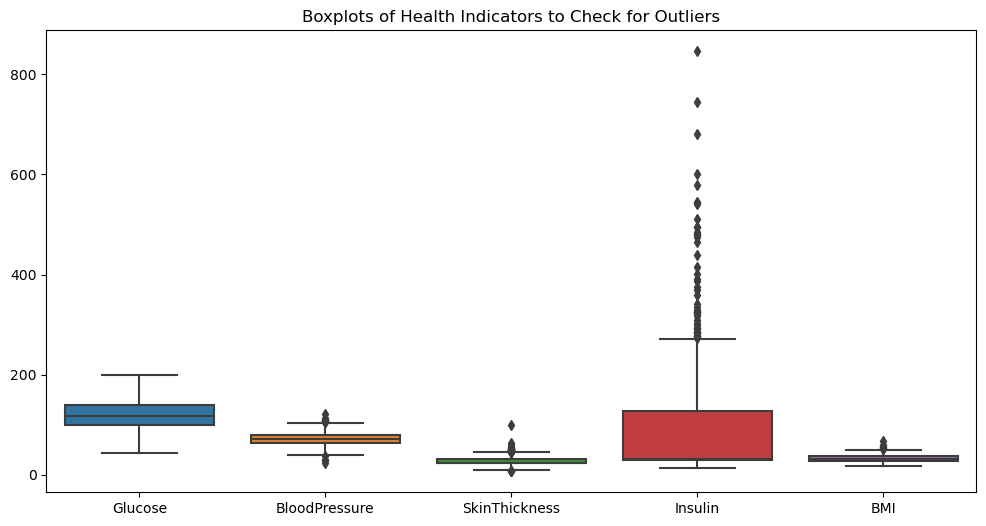

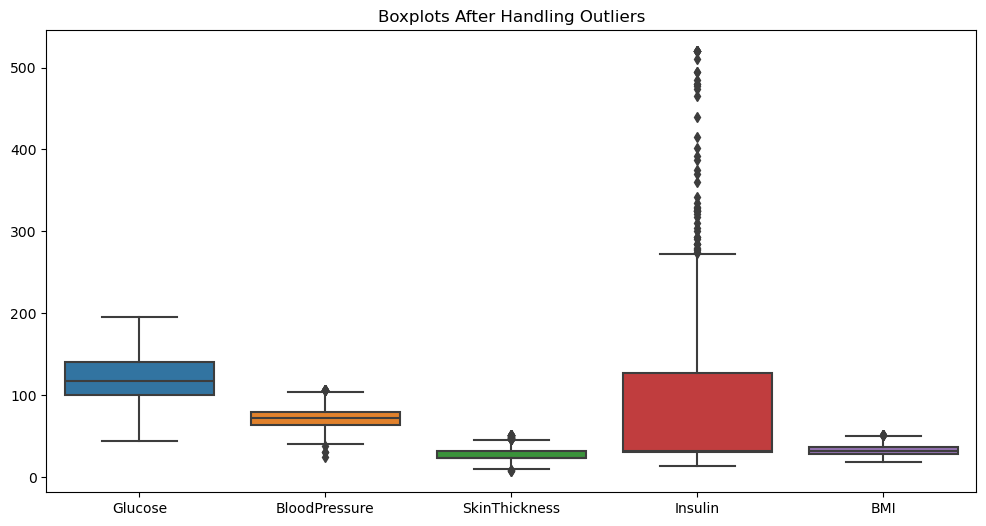

In [4]:
# visualize outliers with boxplots
plt.figure(figsize=(12,6))
sns.boxplot(data=df[cols_with_zeros])
plt.title('Boxplots of Health Indicators to Check for Outliers')
plt.show()

# cap outliers at 99th percentile to limit extreme values
for col in cols_with_zeros:
    upper_limit = df[col].quantile(0.99)
    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])

# recheck boxplots after handling outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=df[cols_with_zeros])
plt.title('Boxplots After Handling Outliers')
plt.show()


In [5]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


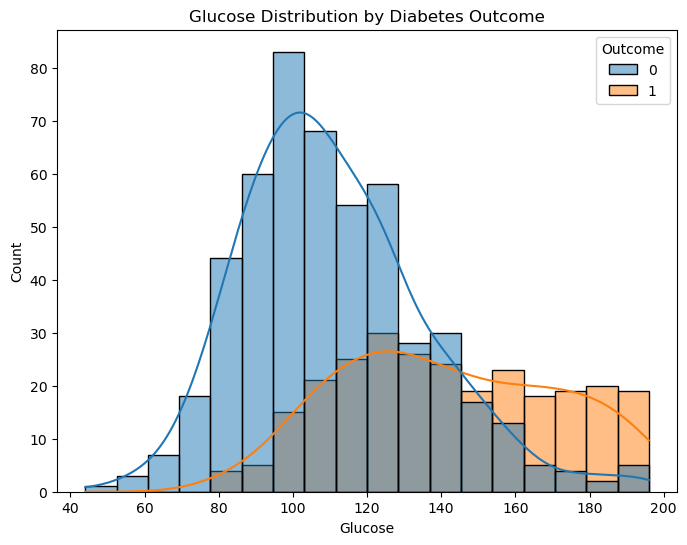

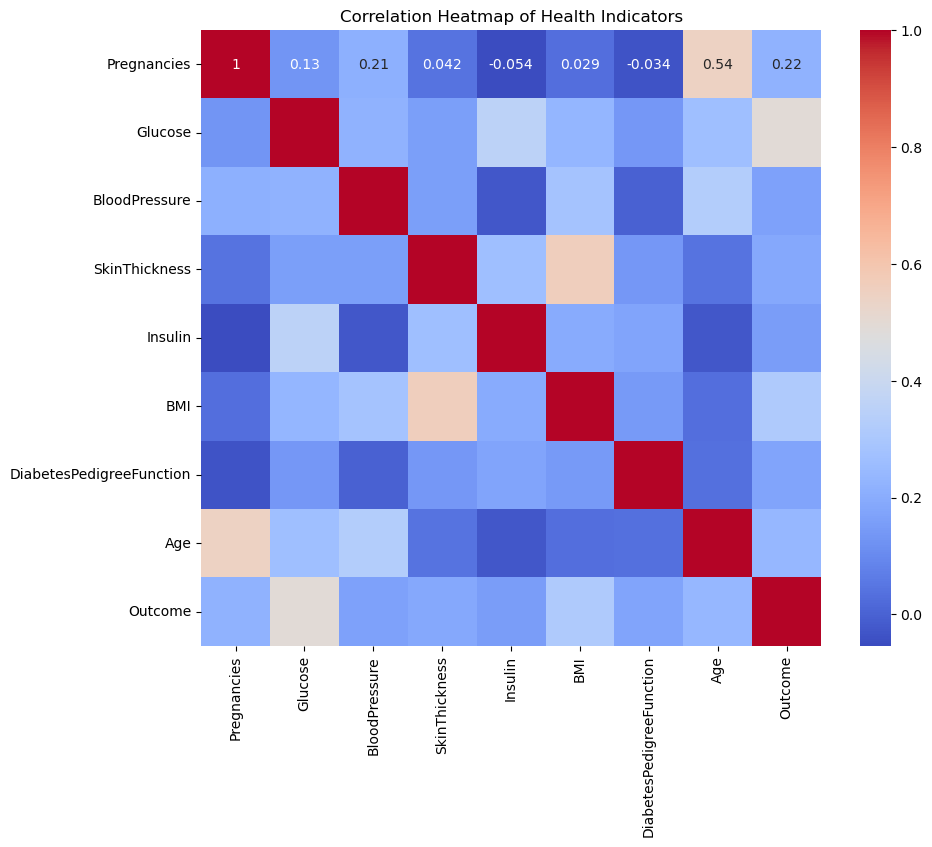

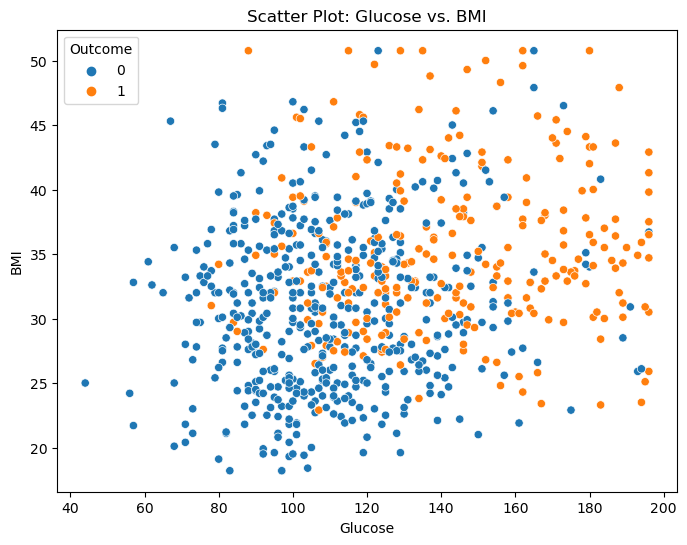

In [6]:
# ensure no infinite or NaN values exist before plotting
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# confirm no NaNs or infinite values remain
print(df.isnull().sum())

# histogram: Glucose distribution by diabetes outcome
plt.figure(figsize=(8,6))
sns.histplot(data=df, x='Glucose', hue='Outcome', kde=True)
plt.title('Glucose Distribution by Diabetes Outcome')
plt.xlabel('Glucose')
plt.ylabel('Count')
plt.show()

# correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Health Indicators')
plt.show()

# scatter plot: Glucose vs. BMI by Outcome
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Glucose', y='BMI', hue='Outcome')
plt.title('Scatter Plot: Glucose vs. BMI')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.show()


In [7]:
# define features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [8]:
# initialize and train Logistic Regression
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# predict using the test set
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]


In [9]:
# accuracy
accuracy = accuracy_score(y_test, y_pred)

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_prob)

# confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# classification Report (precision, recall, f1-score)
class_report = classification_report(y_test, y_pred)

# print results
print(f'Accuracy: {accuracy:.2f}')
print(f'ROC-AUC Score: {roc_auc:.2f}')
print('\nConfusion Matrix:')
print(conf_matrix)
print('\nClassification Report:')
print(class_report)


Accuracy: 0.77
ROC-AUC Score: 0.82

Confusion Matrix:
[[82 17]
 [19 36]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82        99
           1       0.68      0.65      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.77       154



The Logistic Regression model performed fairly well overall, correctly predicting diabetes outcomes in about 77% of cases. A ROC-AUC score of 0.82 also showed that the model is generally effective at distinguishing between diabetic and non-diabetic patients. When looking closer at the results, the model did a particularly good job identifying patients without diabetes, with precision and recall both above 80%. However, it wasn't as strong at correctly recognizing diabetic patients, achieving only moderate precision (68%) and recall (65%). This means the model sometimes missed people who actually had diabetes, and occasionally flagged non-diabetic patients incorrectly. Moving forward, I plan to explore methods to improve the model’s ability to accurately detect diabetic patients. Specifically, I'll try adjusting the decision threshold, using balanced class weights, and experimenting with more powerful models such as Random Forest or XGBoost to achieve better predictive performance.

In [11]:
from sklearn.metrics import classification_report

# Adjust threshold to increase recall
threshold = 0.4
y_pred_adjusted = (y_pred_prob >= threshold).astype(int)

print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.80      0.74      0.77        99
           1       0.59      0.67      0.63        55

    accuracy                           0.71       154
   macro avg       0.69      0.71      0.70       154
weighted avg       0.73      0.71      0.72       154



In [12]:
# retrain model with balanced class weights
model_balanced = LogisticRegression(class_weight='balanced', random_state=42)
model_balanced.fit(X_train, y_train)

# evaluate again
y_pred_balanced = model_balanced.predict(X_test)
print(classification_report(y_test, y_pred_balanced))


              precision    recall  f1-score   support

           0       0.80      0.69      0.74        99
           1       0.55      0.69      0.61        55

    accuracy                           0.69       154
   macro avg       0.68      0.69      0.68       154
weighted avg       0.71      0.69      0.69       154



In [13]:
# Randon Forest model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.82      0.81      0.82        99
           1       0.67      0.69      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



The Random Forest model showed the strongest performance so far, with an overall accuracy of 77%. It also achieved a recall of 69% and precision of 67% for diabetic patients (Outcome = 1), meaning it was able to correctly identify nearly 7 out of 10 true diabetes cases, and most of its positive predictions were accurate. This is an improvement over the earlier Logistic Regression model, which struggled more with catching actual diabetes cases. The model also maintained high precision and recall for non-diabetic patients, making it a more balanced and reliable option. These results suggest that Random Forest is better suited for this type of health prediction.

In [15]:

# import XGBoost and metrics
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# create and train the XGBoost model
xgb_model = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

# make predictions
y_pred_xgb = xgb_model.predict(X_test)
y_pred_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# evaluate the model
accuracy = accuracy_score(y_test, y_pred_xgb)
roc_auc = roc_auc_score(y_test, y_pred_prob_xgb)
conf_matrix = confusion_matrix(y_test, y_pred_xgb)
class_report = classification_report(y_test, y_pred_xgb)

# print the results
print(f"XGBoost Accuracy: {accuracy:.2f}")
print(f"XGBoost ROC-AUC Score: {roc_auc:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


XGBoost Accuracy: 0.73
XGBoost ROC-AUC Score: 0.77

Confusion Matrix:
[[73 26]
 [15 40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.74      0.78        99
           1       0.61      0.73      0.66        55

    accuracy                           0.73       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



The XGBoost model achieved an accuracy of 73% and a ROC-AUC score of 0.77, which is lower than the Random Forest model's 77% accuracy. XGBoost had the highest recall for diabetic patients at 73%, compared to 69% for Random Forest, but its precision was lower at 61%, meaning it produced more false positives. Random Forest remains the most balanced model overall.

Glucose                     0.269
BMI                         0.172
Age                         0.145
DiabetesPedigreeFunction    0.114
BloodPressure               0.081
SkinThickness               0.076
Pregnancies                 0.072
Insulin                     0.071
dtype: float64


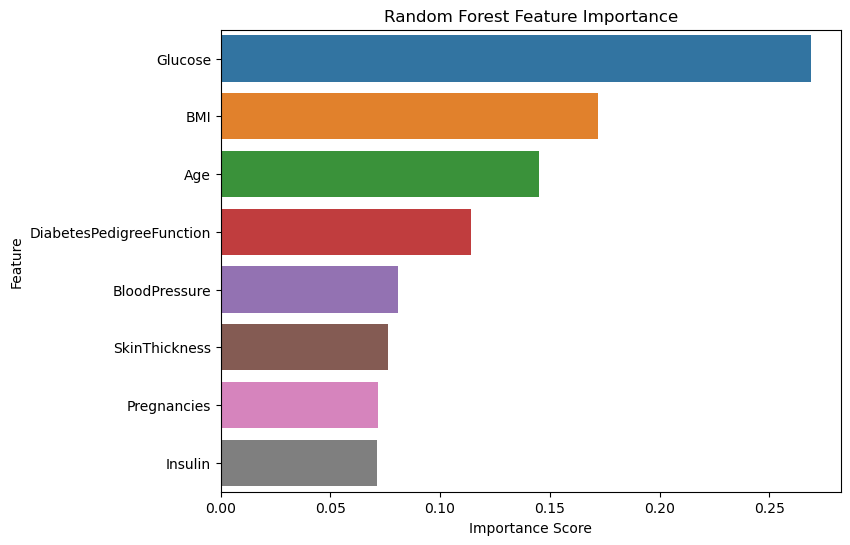

In [17]:
# feature importance from the Random Forest model
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# print the scores
print(importances.round(3))

# plot the scores
plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()